<a href="https://colab.research.google.com/github/zackdihel/DA-project-1/blob/main/lab%209/%5BLab_9%5D_Causal_Inference_and_Propensity_Score_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Load your dataset here (ensure lalonde.csv is uploaded to Colab or linked)
df = pd.read_csv('lalonde.csv')

In [3]:
#step 2: naive comparison
naive_diff = df[df.treat==1]['re78'].mean() - df[df.treat==0]['re78'].mean()
print(f"Naive Difference in Means: ${naive_diff:,.2f}")

Naive Difference in Means: $-635.03


In [4]:
df.describe()

,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.301303,27.363192,10.268730,0.395765,0.117264,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,177.390811,0.459198,9.881187,2.628325,0.489413,0.321997,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,1.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,154.250000,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,307.500000,0.000000,25.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,460.750000,1.000000,32.000000,12.000000,1.000000,0.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,614.000000,1.000000,55.000000,18.000000,1.000000,1.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [5]:
# Define covariates
X = df[['age','educ','black','hispan','married','nodegree','re75','re78']]
y = df['treat']

# Fit Propensity Model
logit = LogisticRegression(solver='liblinear')
logit.fit(X, y)

# Generate Scores
df['pscore'] = logit.predict_proba(X)[:, 1]

#view
df[['treat','pscore']].head()

,treat,pscore
0,1,0.417834
1,1,0.133574
2,1,0.762270
3,1,0.664419
4,1,0.669873


In [6]:
from sklearn.neighbors import NearestNeighbors

# Separate groups
treated = df[df.treat==1]
control = df[df.treat==0]

# Fit NN on Control scores
nbrs = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])

# Find matches for Treated scores
distances, indices = nbrs.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()]

# Construct Matched DataFrame
matched_df = pd.concat([treated, matched_control])

print(f"Original treated size: {len(treated)}")
print(f"Matched control size: {len(matched_control)}")

Original treated size: 185
Matched control size: 185


In [7]:
from scipy import stats

# T-test on raw data
diff = treated['re78'].mean() - control['re78'].mean()
t_stat, p_val = stats.ttest_ind(treated['re78'], control['re78'])

print(f"[Before] Raw Effect (Difference): ${diff:,.2f}")
print(f"[Before] P-value: {p_val:.4f}")

# Isolate the matched outcomes
matched_treated = matched_df[matched_df.treat==1]['re78']
matched_control = matched_df[matched_df.treat==0]['re78']

# Estimate the causal effect (T-test on matched data)
matched_diff = matched_treated.mean() - matched_control.mean()
t_stat, p_val = stats.ttest_ind(matched_treated, matched_control)


print(f"[After] Recovered Effect (Matched Difference): ${matched_diff:,.2f}")
print(f"[After] P-value: {p_val:.4f}")

[Before] Raw Effect (Difference): $-635.03
[Before] P-value: 0.3342
[After] Recovered Effect (Matched Difference): $1,850.03
[After] P-value: 0.0109


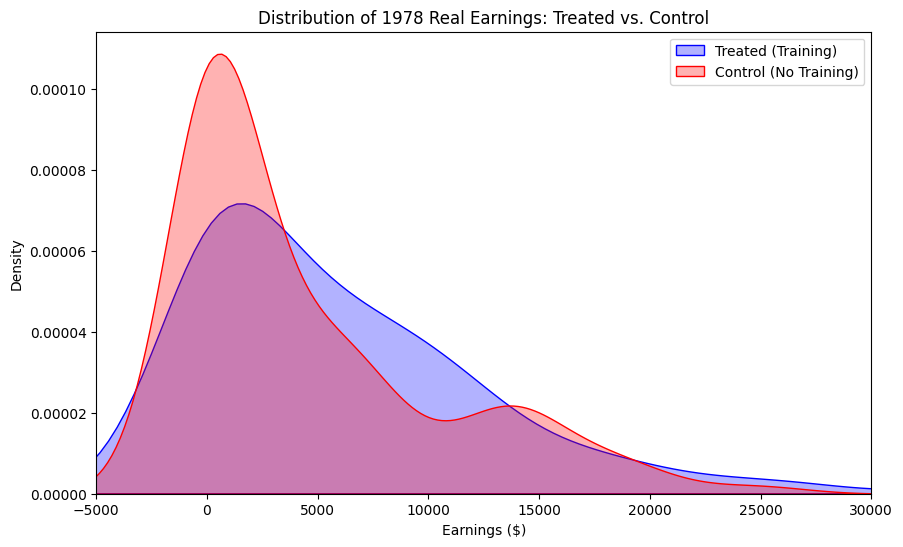

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimate) for both groups
sns.kdeplot(matched_treated, fill=True, label='Treated (Training)', color='blue', alpha=0.3)
sns.kdeplot(matched_control, fill=True, label='Control (No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Real Earnings: Treated vs. Control')
plt.xlabel('Earnings ($)')
plt.xlim(-5000, 30000) # Limit x-axis to focus on the core distribution
plt.legend()
plt.show()


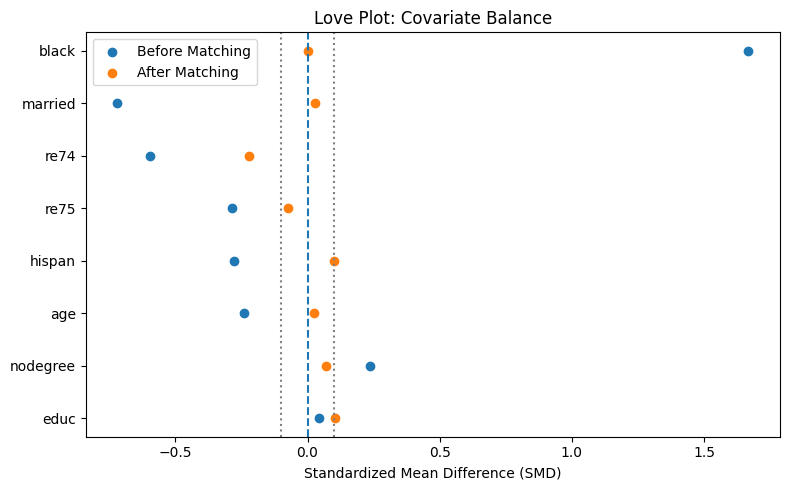

,covariate,before,after
1,educ,0.044755,0.104735
5,nodegree,0.235048,0.070097
0,age,-0.241904,0.023455
3,hispan,-0.276940,0.100359
7,re75,-0.287002,-0.072070
6,re74,-0.595752,-0.221535
4,married,-0.719492,0.027840
2,black,1.667719,0.000000


In [13]:
# Covariates to check balance on (usually pre-treatment vars only)
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

# Loop to compute covariates
covariates = [c for c in covariates if c in df.columns]

# Matched treated/control (aligned by nearest-neighbor output)
# The `matched_control` variable was inadvertently reassigned to a Series in a previous cell.
# Re-extract matched treated and control dataframes from the combined `matched_df`
# to ensure they are DataFrames containing all original columns for covariate balance check.
matched_treated_df = matched_df[matched_df.treat==1].reset_index(drop=True)
matched_control_df = matched_df[matched_df.treat==0].reset_index(drop=True)

def smd(x_t, x_c):
    return (x_t.mean() - x_c.mean()) / np.sqrt((x_t.var(ddof=1) + x_c.var(ddof=1)) / 2)

# Compute SMDs before and after matching
balance = []
for v in covariates:
    smd_before = smd(treated[v], control[v])
    smd_after  = smd(matched_treated_df[v], matched_control_df[v])
    balance.append([v, smd_before, smd_after])

balance_df = pd.DataFrame(balance, columns=['covariate', 'before', 'after'])
balance_df['abs_before'] = balance_df['before'].abs()
balance_df['abs_after'] = balance_df['after'].abs()

# Sort by largest imbalance before matching (optional, makes plot easier to read)
balance_df = balance_df.sort_values('abs_before')

# Love Plot
plt.figure(figsize=(8, 5))
y = np.arange(len(balance_df))

plt.scatter(balance_df['before'], y, label='Before Matching')
plt.scatter(balance_df['after'], y, label='After Matching')

plt.axvline(0, linestyle='--')
plt.axvline(0.1, linestyle=':', color='gray')
plt.axvline(-0.1, linestyle=':', color='gray')

plt.yticks(y, balance_df['covariate'])
plt.xlabel('Standardized Mean Difference (SMD)')
plt.title('Love Plot: Covariate Balance')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: quick table for students
balance_df[['covariate', 'before', 'after']]